# Task 1: Evaluate SDG on TSV Model

Input: headword w, sense definition proposal d for a sense s and a set of retrieved usages U_w for w

Output: New definition d’ for s


In [5]:
import os
import pandas as pd

# preset paths
BASE_DIR = "/home/users1/saxjs/BASax/johannes/autodict/pipeline"
RESULT_DIR = "/home/users1/saxjs/BASax/johannes/eval/results"

print(f"BASE_DIR: {BASE_DIR}")
print(f"RESULT_DIR: {RESULT_DIR}")

BASE_DIR: /home/users1/saxjs/BASax/johannes/autodict/pipeline
RESULT_DIR: /home/users1/saxjs/BASax/johannes/eval/results


In [6]:
def run_outlier2cluster(name, dictionary_s3, usage_path, threshold_s3=0.4, max_usage_length_s3=512):
    """
    Run outlier2cluster analysis for sense definition generation evaluation.
    
    Parameters:
    -----------
    name : str
        Name of the experiment/run
    dictionary_s3 : str
        Path to dictionary file
    usage_path : str
        Path to usage data file
    threshold_s3 : float, default=0.4
        Threshold for outlier2cluster
    max_usage_length_s3 : int, default=512
        Maximum usage length
        
    Returns:
    --------
    pandas.DataFrame
        o2c output results
    """
    
    # Model weights path
    model_weights_s3 = os.path.join(BASE_DIR, "outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl")
    
    
    result_path = f"{RESULT_DIR}/{name}"
    if os.path.exists(result_path):
        o2c_req = True
        print(f"Directory {result_path} already exists")
    else:
        o2c_req = True
        # Create directory if not exists
        os.makedirs(result_path, exist_ok=True)
        print(f"Directory {result_path} created, proceeding with outlier2cluster.")

    # Run outlier2cluster script from the pipeline
    if o2c_req:
        cmd = (
            f'python "{BASE_DIR}/outlier2cluster/o2c/code/main.py" '
            f'--dictionary "{dictionary_s3}" '
            f'--usages "{usage_path}" '
            f'--thresh "{threshold_s3}" '
            f'--result_dir "{result_path}" '
            f'--nsd_weights "{model_weights_s3}" '
            f'--context_limit "{max_usage_length_s3}"'
        )
        print("Running:", cmd)
        os.system(cmd)

    # Load S3 results
    s3out = pd.read_csv(f"{result_path}/result_raw.tsv", sep='\t')
    #print("S3 Output Preview:")
    #print(s3out.head(2))
    
    return s3out

In [7]:
import time

def create_tsv_format_foro2c(dictionary, usages):
    """
    Create TSV format data and run o2c.
    
    Parameters:
    -----------
    dictionary : string
        path to dictionary file
    usages : string
        path to usages file

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing the dataset
    """
    
    step_sense_path= f"{RESULT_DIR}/sense_step.tsv"
    step_usage_path = f"{RESULT_DIR}/usage_tsv_step.tsv"


    # Load dictionary and usages
    dict_df = pd.read_csv(dictionary, sep='\t')
    usages_df = pd.read_csv(usages, sep='\t')

    # Remove dictionary entries with no usages
    print("Removing dictionary entries with no usages... current size:", len(dict_df))
    dict_df = dict_df[dict_df['sense_id'].isin(usages_df['sense_id_gold'])]
    print("New dictionary size:", len(dict_df))

    #same columns as usages_df
    full_dataset = pd.DataFrame(columns=usages_df.columns)

    # Iterate over dictionary entries grouped by lemma
    grouped_dict = dict_df.groupby('lemma')
    stop=0

    for lemma, group in grouped_dict:
        usages_for_sense = usages_df[usages_df['lemma'] == lemma].copy()  # Create explicit copy
        for i, row in group.iterrows():
            # Get usages for the current sense_id
            sense_id = row['sense_id']
            # Create tsv_label 1 for correlated usages, 0 for outliers
            usages_for_sense.loc[:, 'tsv_label'] = 0  # Initialize all to 0
            usages_for_sense.loc[usages_for_sense['sense_id_gold'] == sense_id, 'tsv_label'] = 1

            usages_for_sense.to_csv(f"{RESULT_DIR}/usage_tsv_step.tsv", sep='\t', index=False)
            #create dataset from current row
            sense_inv_step = group.copy()
            #remove all but current row
            sense_inv_step = sense_inv_step[sense_inv_step['sense_id'] == sense_id]
            # Save the sense_inv_step to a file
            sense_inv_step.to_csv(f"{RESULT_DIR}/sense_step.tsv", sep='\t', index=False)

            # start timer
            start_time = time.time()

            
            #run 02c now
            o2c_output_step = run_outlier2cluster(
                    name="o2c_step",
                    dictionary_s3=step_sense_path,
                    usage_path=step_usage_path,
                    threshold_s3=0.4,
                    max_usage_length_s3=512)
            
            full_dataset = pd.concat([full_dataset, o2c_output_step], ignore_index=True)
            # end timer
            end_time = time.time()
            elapsed_time = end_time - start_time
            print(f"Processed lemma '{lemma}' in {elapsed_time:.2f} seconds.")
            break  # Stop after processing the first lemma

        stop += 1
        if stop > 20:
            print("Stopping after processing 20 lemmas.")
            break  # Stop after processing the first 20 lemmas

    
    return full_dataset

# MAIN

In [8]:
# Example usage of the outlier2cluster analysis function
name = "test_generated_definition"  # fews_short_generated_definition #"s1_t_0_19_s3_gen_def_gen_def_usages"

# Define paths
dictionary_path = "/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/sense_inv_lem+notlem.tsv"
usage_path = "/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/gold_data_fews.tsv"


full_tsv_run=create_tsv_format_foro2c(dictionary_path, usage_path)


Removing dictionary entries with no usages... current size: 22725
New dictionary size: 3886
Directory /home/users1/saxjs/BASax/johannes/eval/results/o2c_step already exists
Running: python "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/code/main.py" --dictionary "/home/users1/saxjs/BASax/johannes/eval/results/sense_step.tsv" --usages "/home/users1/saxjs/BASax/johannes/eval/results/usage_tsv_step.tsv" --thresh "0.4" --result_dir "/home/users1/saxjs/BASax/johannes/eval/results/o2c_step" --nsd_weights "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl" --context_limit "512"


23:39:28 - INFO - Transform files to axolotl format
23:39:28 - INFO - Prepare required models
23:39:28 - INFO - Gloss Reader model.safetensors already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR_FiEnRu/model.safetensors, skip download.
23:39:28 - INFO - Gloss Reader model.pt already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt, skip download.
23:39:28 - INFO - Start vectorization of dictionary entries and usages
23:39:46 - INFO - Run gr_wsd.py for wsd
23:39:46 - INFO - Run gr_wsd.py for wsd
100%|██████████| 1/1 [00:00<00:00, 33.43it/s]
23:40:20 - INFO - Run Agglomerative.py for wsi clustering
23:40:20 - INFO - Run Agglomerative.py for wsi clustering
0it [00:00, ?it/s]
0it [00:00, ?it/s]
23:40:32 - INFO - Run outlier2cluster.py
23:40:32 - INFO - Run outlier2cluster.py
23:40:49 - INFO - Apply threshold 0.4
23:40:49 - INFO - Out of a total of 1 

Processed lemma 'A cup' in 82.87 seconds.
Directory /home/users1/saxjs/BASax/johannes/eval/results/o2c_step already exists
Running: python "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/code/main.py" --dictionary "/home/users1/saxjs/BASax/johannes/eval/results/sense_step.tsv" --usages "/home/users1/saxjs/BASax/johannes/eval/results/usage_tsv_step.tsv" --thresh "0.4" --result_dir "/home/users1/saxjs/BASax/johannes/eval/results/o2c_step" --nsd_weights "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl" --context_limit "512"


23:40:50 - INFO - Transform files to axolotl format
23:40:50 - INFO - Prepare required models
23:40:50 - INFO - Gloss Reader model.safetensors already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR_FiEnRu/model.safetensors, skip download.
23:40:50 - INFO - Gloss Reader model.pt already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt, skip download.
23:40:50 - INFO - Start vectorization of dictionary entries and usages
23:41:05 - INFO - Run gr_wsd.py for wsd
23:41:05 - INFO - Run gr_wsd.py for wsd
100%|██████████| 1/1 [00:00<00:00, 168.16it/s]
23:41:15 - INFO - Run Agglomerative.py for wsi clustering
23:41:15 - INFO - Run Agglomerative.py for wsi clustering
0it [00:00, ?it/s]
0it [00:00, ?it/s]
23:41:24 - INFO - Run outlier2cluster.py
23:41:24 - INFO - Run outlier2cluster.py
23:41:41 - INFO - Apply threshold 0.4
23:41:41 - INFO - Out of a total of 1

Processed lemma 'ABD' in 52.59 seconds.
Directory /home/users1/saxjs/BASax/johannes/eval/results/o2c_step already exists
Running: python "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/code/main.py" --dictionary "/home/users1/saxjs/BASax/johannes/eval/results/sense_step.tsv" --usages "/home/users1/saxjs/BASax/johannes/eval/results/usage_tsv_step.tsv" --thresh "0.4" --result_dir "/home/users1/saxjs/BASax/johannes/eval/results/o2c_step" --nsd_weights "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl" --context_limit "512"


...

23:56:35 - INFO - Transform files to axolotl format
23:56:35 - INFO - Prepare required models
23:56:35 - INFO - Gloss Reader model.safetensors already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR_FiEnRu/model.safetensors, skip download.
23:56:35 - INFO - Gloss Reader model.pt already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt, skip download.
23:56:35 - INFO - Start vectorization of dictionary entries and usages
23:56:50 - INFO - Run gr_wsd.py for wsd
23:56:50 - INFO - Run gr_wsd.py for wsd
100%|██████████| 1/1 [00:00<00:00, 266.09it/s]
23:57:01 - INFO - Run Agglomerative.py for wsi clustering
23:57:01 - INFO - Run Agglomerative.py for wsi clustering
0it [00:00, ?it/s]
0it [00:00, ?it/s]
23:57:10 - INFO - Run outlier2cluster.py
23:57:10 - INFO - Run outlier2cluster.py
23:57:26 - INFO - Apply threshold 0.4
23:57:26 - INFO - Out of a total of 1

Processed lemma 'Bank' in 52.50 seconds.
Directory /home/users1/saxjs/BASax/johannes/eval/results/o2c_step already exists
Running: python "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/code/main.py" --dictionary "/home/users1/saxjs/BASax/johannes/eval/results/sense_step.tsv" --usages "/home/users1/saxjs/BASax/johannes/eval/results/usage_tsv_step.tsv" --thresh "0.4" --result_dir "/home/users1/saxjs/BASax/johannes/eval/results/o2c_step" --nsd_weights "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl" --context_limit "512"


23:57:27 - INFO - Transform files to axolotl format
23:57:27 - INFO - Prepare required models
23:57:27 - INFO - Gloss Reader model.safetensors already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR_FiEnRu/model.safetensors, skip download.
23:57:27 - INFO - Gloss Reader model.pt already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt, skip download.
23:57:27 - INFO - Start vectorization of dictionary entries and usages
23:57:43 - INFO - Run gr_wsd.py for wsd
23:57:43 - INFO - Run gr_wsd.py for wsd
100%|██████████| 1/1 [00:00<00:00, 255.81it/s]
23:57:53 - INFO - Run Agglomerative.py for wsi clustering
23:57:53 - INFO - Run Agglomerative.py for wsi clustering
0it [00:00, ?it/s]
0it [00:00, ?it/s]
23:58:02 - INFO - Run outlier2cluster.py
23:58:02 - INFO - Run outlier2cluster.py
23:58:19 - INFO - Apply threshold 0.4
23:58:19 - INFO - Out of a total of 1

Processed lemma 'Barak' in 52.25 seconds.
Stopping after processing 20 lemmas.


23:58:19 - INFO - Execution DONE. See results in /home/users1/saxjs/BASax/johannes/eval/results/o2c_step


In [24]:
full_tsv_run.to_csv(f"{RESULT_DIR}/20lemma_tsv_run.tsv", sep='\t')


## Evaluate now

In [28]:
#load the full tsv run
full_tsv_run=pd.read_csv(f"{RESULT_DIR}/20lemma_tsv_run.tsv", sep='\t')

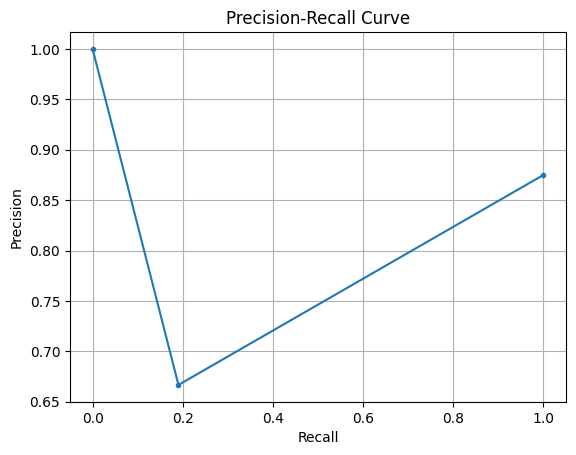

Calculating F1 Score...
F1 Score: 0.2962962962962963
Calculating Accuracy...
Hamming Loss: 0.7916666666666666
Accuracy: 0.20833333333333334


In [29]:

gold_label = full_tsv_run['tsv_label'].to_list()
test_label = full_tsv_run['prob'].to_list()
test_label = [0 if x > 0.3 else 1 for x in test_label]  # Convert probabilities to binary labels

# Plot Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
precision, recall, thresholds = precision_recall_curve(gold_label, test_label)
#plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()

from sklearn.metrics import f1_score
print("Calculating F1 Score...")
f1 = f1_score(gold_label, test_label)
print("F1 Score:", f1)
print("Calculating Accuracy...")
from sklearn.metrics import accuracy_score, hamming_loss
hamming = hamming_loss(gold_label, test_label)
print("Hamming Loss:", hamming)
accuracy = accuracy_score(gold_label, test_label)
print("Accuracy:", accuracy)